# 07. Model Evaluation

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute accuracy, precision, recall, F1
- Use cross-validation and learning curves
- Interpret evaluation plots and metrics

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## The Story

**BEFORE**: You know how to build ML models, but don't know how to properly evaluate their performance beyond accuracy.

**AFTER**: You'll master comprehensive model evaluation with cross-validation, precision, recall, F1-score, and learning curves!

**Why this matters**: Proper model evaluation is essential for building reliable, production-ready ML systems!

---

# Unit 4 - Example 7: Model Evaluation

## 🔗 Solving the Problem from Example 6

**Remember the dead end from Example 6?**
- We learned to build classification models
- But we discovered accuracy alone can be misleading
- We need comprehensive evaluation beyond just accuracy

**This notebook solves that problem!**
- We'll learn **comprehensive evaluation metrics** (precision, recall, F1, AUC)
- We'll learn **cross-validation** for robust performance estimation
- We'll learn **learning curves** to understand model behavior

**This solves the evaluation problem from Example 6!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Trained model
- Test set

**Outputs:** What you'll see when you run the cells

- Metrics (accuracy, precision, recall, etc.)
- Plots

---

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, learning_curve)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("Example 7: Model Evaluation")
print("=" * 70)
print("\n📚 Prerequisites: Examples 04–06 completed, ML model knowledge")
print("🔗 This is Example 7 in Unit 4 - model evaluation")
print("🎯 Goal: Master model evaluation with cross-validation and metrics")

Example 7: Model Evaluation

📚 Prerequisites: Examples 04–06 completed, ML model knowledge
🔗 This is Example 7 in Unit 4 - model evaluation
🎯 Goal: Master model evaluation with cross-validation and metrics


1. CROSS-VALIDATION


In [2]:
print("\n1. Cross Validation")
print("-" * 70)
np.random.seed(42)
n_samples = 300
X = np.random.randn(n_samples, 4)
y = X[:, 0] * 2 + X[:, 1] * 1.5 - X[:, 2] * 0.5 + np.random.randn(n_samples) * 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
# K-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


1. Cross Validation
----------------------------------------------------------------------

5-Fold Cross-Validation R² Scores:
  Fold 1: 0.9978
  Fold 2: 0.9980
  Fold 3: 0.9976
  Fold 4: 0.9987
  Fold 5: 0.9985

Mean CV Score: 0.9981 (+/- 0.0008)


2. LEARNING CURVES




2. Learning Curves
----------------------------------------------------------------------


✓ Learning curves saved


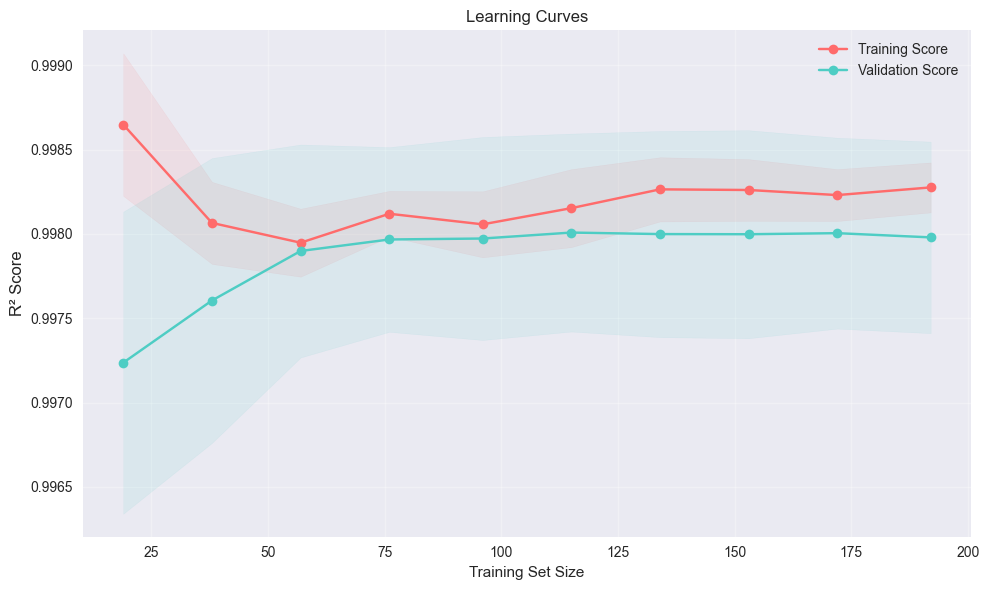

In [3]:
print("\n\n2. Learning Curves")
print("-" * 70)
train_sizes, train_scores, val_scores = learning_curve(
model, X_train, y_train, cv=5, n_jobs=-1,
train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#FF6B6B', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#FF6B6B')
plt.plot(train_sizes, val_mean, 'o-', color='#4ECDC4', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#4ECDC4')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('12_learning_curves.png', dpi=300, bbox_inches='tight')
print("✓ Learning curves saved")
plt.show()
plt.close()

3. MULTIPLE METRICS EVALUATION


In [4]:
print("\n\n3. Multiple Metrics Evaluation")
print("-" * 70)
# Classification metrics
np.random.seed(42)
X_clf = np.random.randn(200, 3)
y_clf = (X_clf[:, 0] + X_clf[:, 1] > 0).astype(int)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)
clf_model = LogisticRegression(random_state=42)
clf_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf_scaled)
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
print("\nClassification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")



3. Multiple Metrics Evaluation
----------------------------------------------------------------------

Classification Metrics:
  Accuracy:  0.9500
  Precision: 0.9412
  Recall:    0.9412
  F1 Score:  0.9412


# 07. MODEL COMPARISON



4. Model Comparison
----------------------------------------------------------------------

Model Comparison:
                     Accuracy  Precision  Recall      F1
Logistic Regression      0.95     0.9412  0.9412  0.9412
Decision Tree            0.90     0.8421  0.9412  0.8889
✓ Model comparison saved


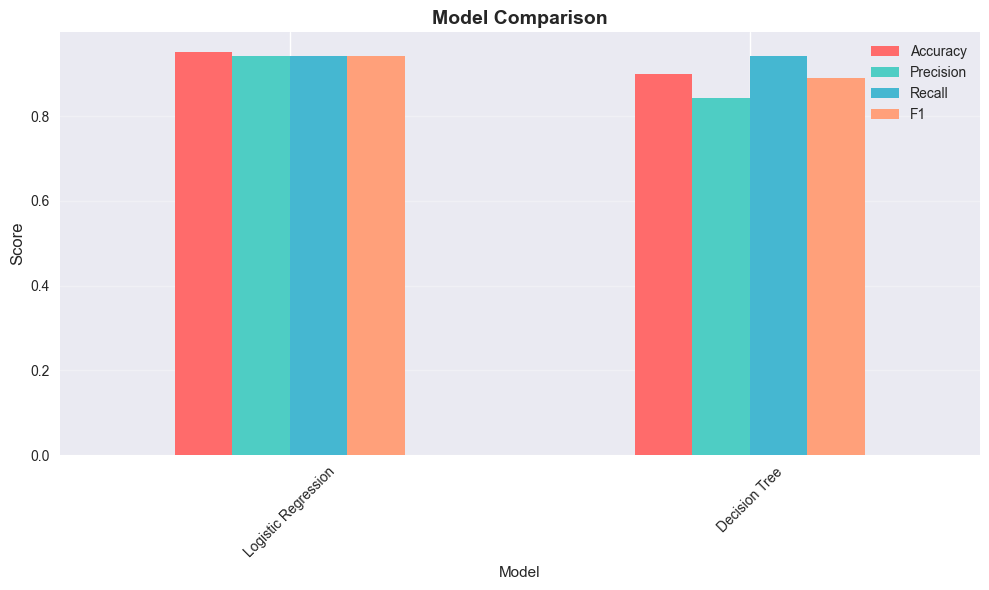

In [5]:
print("\n\n4. Model Comparison")
print("-" * 70)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5)
}
results = {}
for name, model in models.items():
    model.fit(X_train_clf_scaled, y_train_clf)
    y_pred = model.predict(X_test_clf_scaled)
    results[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred),
        'Recall': recall_score(y_test_clf, y_pred),
        'F1': f1_score(y_test_clf, y_pred)
    }
comparison_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(comparison_df.round(4))
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_title('Model Comparison', fontsize=14, weight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('12_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Model comparison saved")
plt.show()
plt.close()

# 5. SUMMARY


In [6]:
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. Cross-validation techniques")
print("2. Learning curves")
print("3. Multiple evaluation metrics")
print("4. Model comparison")
print("\nNext Steps: Continue to Example 08 for Hyperparameter Tuning")



Summary

Key Concepts Covered:
1. Cross-validation techniques
2. Learning curves
3. Multiple evaluation metrics
4. Model comparison

Next Steps: Continue to Example 08 for Hyperparameter Tuning


## 🚫 When Model Evaluation Hits a Dead End

**BEFORE**: We've learned comprehensive model evaluation techniques.

**AFTER**: We discover that model *selection* multiplies evaluation cost — and we measure exactly how much.

**Why this matters**: A single evaluation is cheap. Real workflows run hundreds of fits, and the cost is multiplicative: parameter combinations × CV folds × per-fit time.

---

### The Problem We've Discovered

We've learned:
- ✅ How to evaluate models comprehensively (cross-validation, metrics)
- ✅ How to compare models and understand performance
- ✅ How to create learning curves

**But we have a problem:**
- A single 5-fold cross-validation of a cheap model is fast (we measure it below)
- Choosing a model honestly means grid search: every parameter combination × every fold
- With a slower model (e.g. a random forest), that multiplication gets expensive quickly

**The Dead End:**
- Evaluation cost = (parameter combinations) × (CV folds) × (single-fit time)
- No guessing — the next cell times both a cheap baseline and a real grid search on this machine

---

### Demonstrating the Problem

First a cheap baseline, then a real grid search — both timed:

In [7]:
print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: The Real Cost of Model Selection")
print("=" * 70)

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# A larger dataset than the ones above
np.random.seed(42)
n_samples_large = 10_000
X_large = np.random.randn(n_samples_large, 10)
y_large = (X_large[:, 0] + X_large[:, 1] + 0.5 * np.random.randn(n_samples_large) > 0).astype(int)
print(f"\n📊 Dataset: {n_samples_large:,} samples × 10 features")

# --- Baseline: ONE cheap model, 5-fold CV ---
print("\n⏱️  Baseline: single LogisticRegression + 5-fold CV")
start_time = time.time()
baseline_scores = cross_val_score(LogisticRegression(max_iter=1000), X_large, y_large, cv=5)
baseline_time = time.time() - start_time
print(f"   Completed in {baseline_time:.2f} seconds (mean accuracy: {baseline_scores.mean():.4f})")
print("   → A single evaluation of a cheap model is FAST.")

# --- The real cost: grid search over a slower model ---
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [8, None]}
n_combos = 3 * 2
n_folds = 5
n_fits = n_combos * n_folds + 1  # +1 final refit on the full data
print(f"\n⏱️  Model selection: RandomForest grid search")
print(f"   Grid: {param_grid}")
print(f"   {n_combos} combinations × {n_folds} folds (+1 final refit) = {n_fits} model fits")

start_time = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid, cv=n_folds, n_jobs=1)  # single core: what one CPU core actually does
grid_search.fit(X_large, y_large)
grid_time = time.time() - start_time

print(f"   Completed in {grid_time:.1f} seconds ({grid_time / n_fits:.2f} s per fit)")
print(f"   Best params: {grid_search.best_params_} (CV accuracy: {grid_search.best_score_:.4f})")

print(f"\n⚠️  What we measured (this machine, single core):")
print(f"   - One cheap evaluation:   {baseline_time:.2f} s")
print(f"   - One modest grid search: {grid_time:.1f} s — about {grid_time / baseline_time:.0f}x more")

per_fit = grid_time / n_fits
print(f"\n💡 The multiplication problem (arithmetic from the measured {per_fit:.2f} s/fit):")
for combos, data_factor, label in [
        (60, 1, "bigger grid (60 combos, 5 folds)"),
        (60, 10, "bigger grid + 10x more data")]:
    est = combos * 5 * per_fit * data_factor
    print(f"   - {label}: {combos * 5} fits → est. ~{est / 60:.0f} minutes")
print("   (These are linear extrapolations of the measured per-fit time, NOT")
print("    measurements. Tree training scales roughly linearly in sample count.)")

print(f"\n➡️  Solution Needed:")
print(f"   - Parallelism (n_jobs=-1) helps, but cores are limited")
print(f"   - GPU-accelerated ML libraries (cuML, XGBoost GPU) attack the per-fit time")
print(f"   - This leads us to Example 12: CPU vs GPU for ML")
print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: The Real Cost of Model Selection

📊 Dataset: 10,000 samples × 10 features

⏱️  Baseline: single LogisticRegression + 5-fold CV
   Completed in 0.02 seconds (mean accuracy: 0.8953)
   → A single evaluation of a cheap model is FAST.

⏱️  Model selection: RandomForest grid search
   Grid: {'n_estimators': [50, 100, 200], 'max_depth': [8, None]}
   6 combinations × 5 folds (+1 final refit) = 31 model fits


   Completed in 26.8 seconds (0.86 s per fit)
   Best params: {'max_depth': 8, 'n_estimators': 200} (CV accuracy: 0.8933)

⚠️  What we measured (this machine, single core):
   - One cheap evaluation:   0.02 s
   - One modest grid search: 26.8 s — about 1724x more

💡 The multiplication problem (arithmetic from the measured 0.86 s/fit):
   - bigger grid (60 combos, 5 folds): 300 fits → est. ~4 minutes
   - bigger grid + 10x more data: 300 fits → est. ~43 minutes
   (These are linear extrapolations of the measured per-fit time, NOT
    measurements. Tree training scales roughly linearly in sample count.)

➡️  Solution Needed:
   - Parallelism (n_jobs=-1) helps, but cores are limited
   - GPU-accelerated ML libraries (cuML, XGBoost GPU) attack the per-fit time
   - This leads us to Example 12: CPU vs GPU for ML



### What We Need Next

**The Solution**: We need to attack the per-fit time:
- **Parallel CPU search**: `n_jobs=-1` divides the fits across cores — helpful, but bounded by core count
- **GPU-accelerated ML**: libraries like cuML and XGBoost's GPU mode parallelize the fit itself
- **A note on numbers**: vendors publish order-of-magnitude GPU training speedups on large datasets; those are *their published benchmarks*, not something this notebook measured

**Where this dead end leads:**
- Example 08 (next) runs grid and random search for real — the workflow side of the cost problem
- Example 12 examines GPU acceleration for ML — the hardware side
- The measured multiplication above (combinations × folds × per-fit time) is exactly the cost both of them attack